<a href="https://colab.research.google.com/github/mithesh6/dip_project/blob/main/DIP(PROJECT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [6]:
!unzip "/content/gdrive/MyDrive/CNN_assignment.zip" > /dev/null

In [7]:
import pathlib
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import PIL

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

from tensorflow.keras.preprocessing.image import load_img

In [8]:
data_dir_train = pathlib.Path("/content/Skin cancer ISIC The International Skin Imaging Collaboration/Train/")
data_dir_test = pathlib.Path("/content/Skin cancer ISIC The International Skin Imaging Collaboration/Test/")

In [9]:
# Count the number of image in Train and Test directory
# Using the glob to retrieve files/pathnames matching a specified pattern.

#Train Image count
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)

#Test Image count
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

2239
118


Found 2239 files belonging to 9 classes.


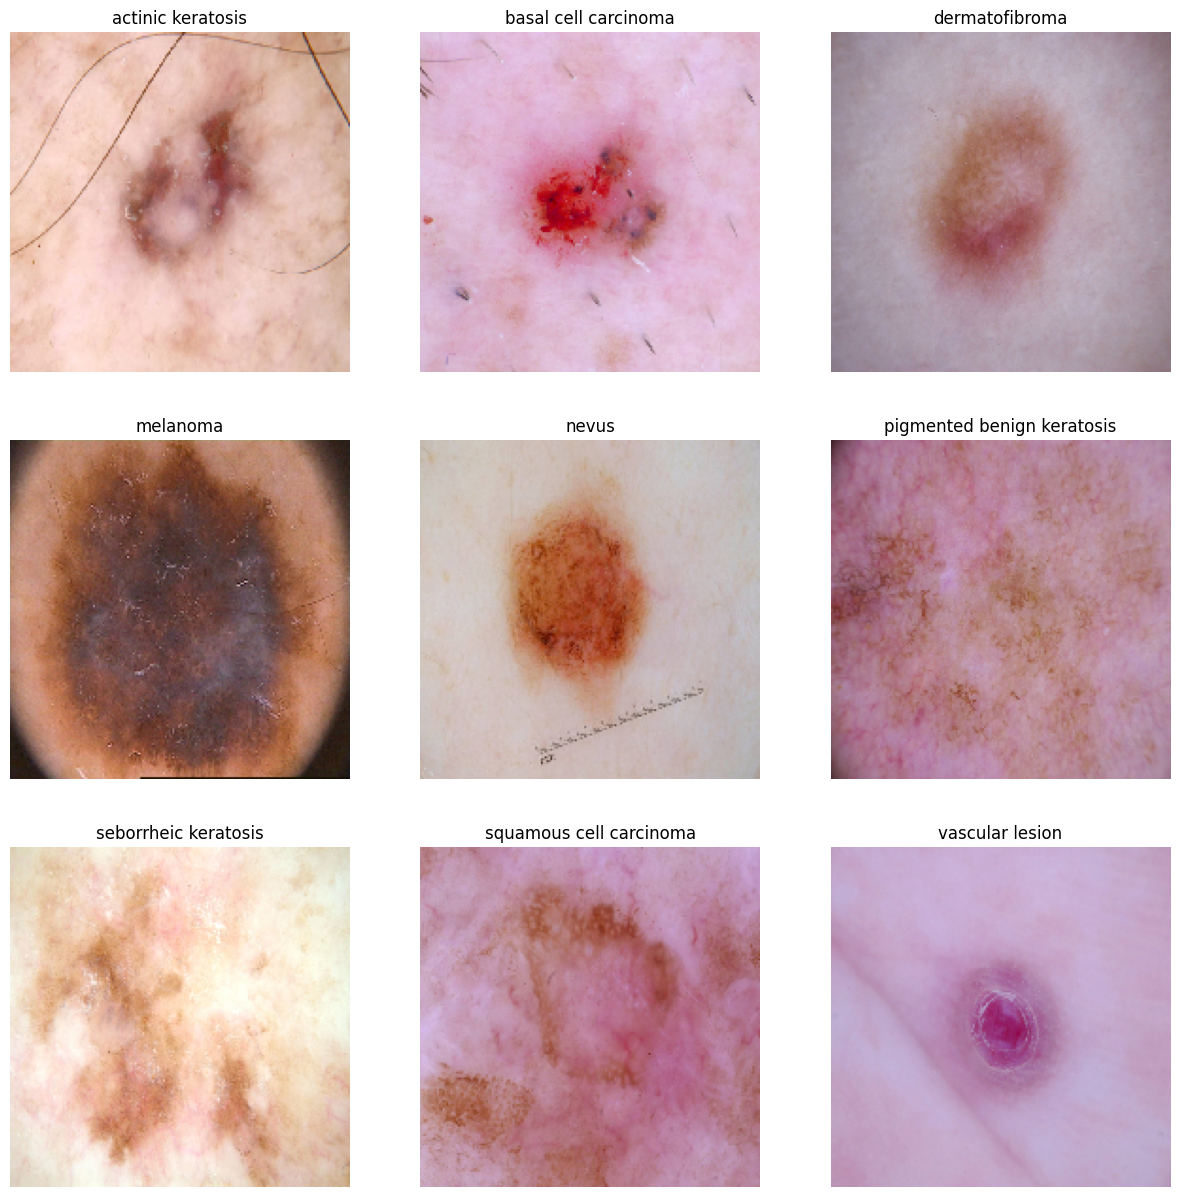

In [10]:
#Visualize one instance of all the class present in the dataset.

#image_dataset_from_directory() will return a tf.data.Dataset that yields batches of images from the subdirectories.
#label_mode is categorial, the labels are a float32 tensor of shape (batch_size, num_classes), representing a one-hot encoding of the class index.
image_dataset = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train,batch_size=32,image_size=(180,180),
                                                                    label_mode='categorical',seed=123)

#all the classes of Skin Cancer
class_names = image_dataset.class_names

#Dictionary to store the path of image as per the class
files_path_dict = {}

for c in class_names:
    files_path_dict[c] = list(map(lambda x:str(data_dir_train)+'/'+c+'/'+x,os.listdir(str(data_dir_train)+'/'+c)))

#Visualize image
plt.figure(figsize=(15,15))
index = 0
for c in class_names:
    path_list = files_path_dict[c][:1]
    index += 1
    plt.subplot(3,3,index)
    plt.imshow(load_img(path_list[0],target_size=(180,180)))
    plt.title(c)
    plt.axis("off")

In [11]:
def class_distribution_count(directory):

    #count number of image in each classes
    count= []
    for path in pathlib.Path(directory).iterdir():
        if path.is_dir():
            count.append(len([name for name in os.listdir(path)
                               if os.path.isfile(os.path.join(path, name))]))

    #name of the classes
    sub_directory = [name for name in os.listdir(directory)
                    if os.path.isdir(os.path.join(directory, name))]

    #return dataframe with image count and class.
    return pd.DataFrame(list(zip(sub_directory,count)),columns =['Class', 'No. of Image'])

df = class_distribution_count(data_dir_train)
df

,Class,No. of Image
0,dermatofibroma,95
1,pigmented benign keratosis,462
2,nevus,357
3,melanoma,438
4,basal cell carcinoma,376
5,seborrheic keratosis,77
6,vascular lesion,139
7,actinic keratosis,114
8,squamous cell carcinoma,181


<Axes: xlabel='No. of Image', ylabel='Class'>

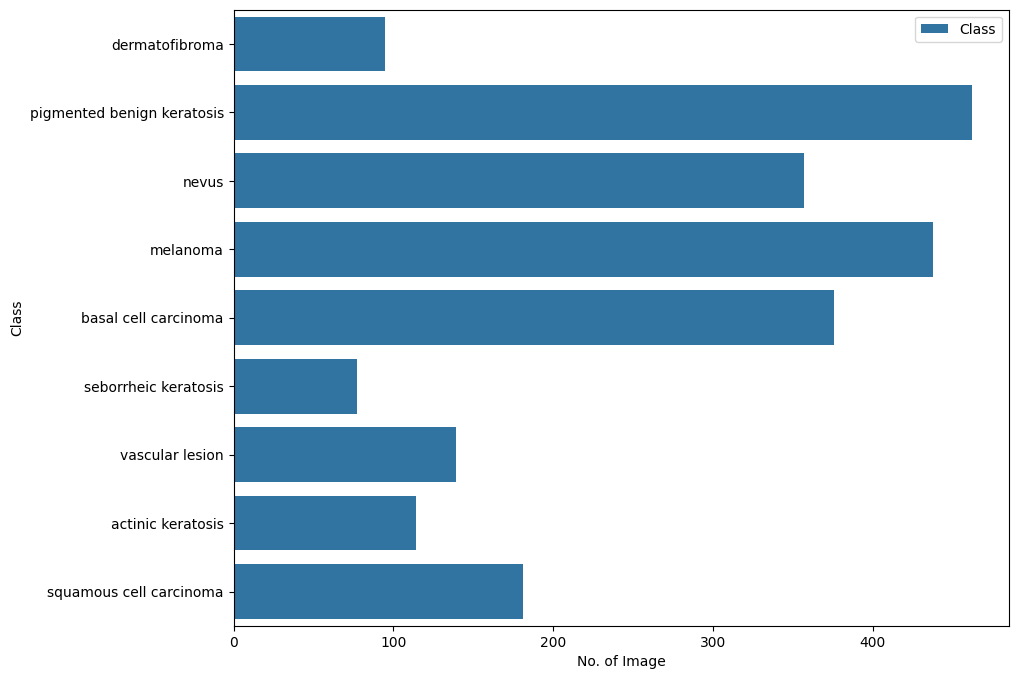

In [12]:
#Visualize the Number of image in each class.
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.barplot(x="No. of Image", y="Class", data=df,
            label="Class")

In [13]:
!pip install Augmentor

Saving ISIC_0011193.jpg to ISIC_0011193 (1).jpg


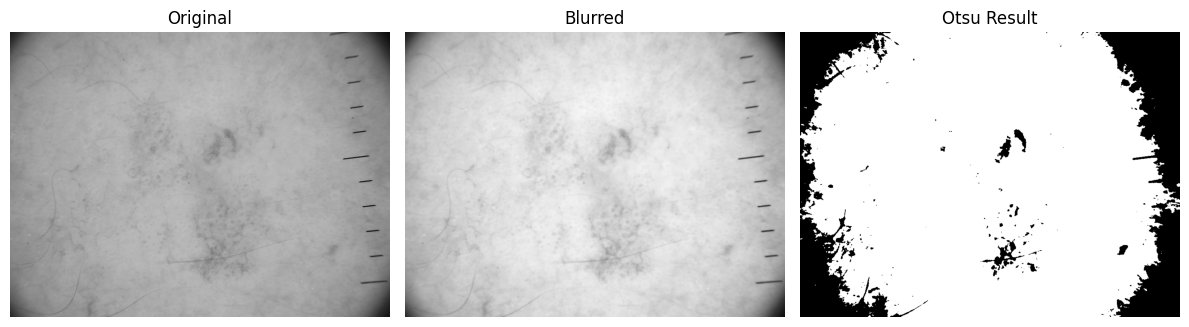

(None, None)

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files # Import files module

# Perform the upload
uploaded = files.upload()

# Pick the first uploaded image
image_path = list(uploaded.keys())[0]

# Load in grayscale
gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
blur = cv2.GaussianBlur(gray_img, (5, 5), 0)
ret, otsu_segmented = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Show result
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.title("Original"), plt.imshow(gray_img, cmap='gray'), plt.axis('off')
plt.subplot(1, 3, 2), plt.title("Blurred"), plt.imshow(blur, cmap='gray'), plt.axis('off')
plt.subplot(1, 3, 3), plt.title("Otsu Result"), plt.imshow(otsu_segmented, cmap='gray'), plt.axis('off')
plt.tight_layout(), plt.show()

In [15]:

path_to_training_dataset="/content/Skin cancer ISIC The International Skin Imaging Collaboration/Train/"
import Augmentor
for i in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + i)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500)  #Adding 500 samples per class to make sure that none of the classes are sparse

Initialised with 114 image(s) found.
Output directory set to /content/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7D3D52D28ED0>: 100%|██████████| 500/500 [00:23<00:00, 21.22 Samples/s]


Initialised with 376 image(s) found.
Output directory set to /content/Skin cancer ISIC The International Skin Imaging Collaboration/Train/basal cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7D3D52E70FD0>: 100%|██████████| 500/500 [00:22<00:00, 22.64 Samples/s]


Initialised with 95 image(s) found.
Output directory set to /content/Skin cancer ISIC The International Skin Imaging Collaboration/Train/dermatofibroma/output.

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x7D3D52D2CE10>: 100%|██████████| 500/500 [00:43<00:00, 11.39 Samples/s]


Initialised with 181 image(s) found.
Output directory set to /content/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma/output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x7D3D52D538D0>: 100%|██████████| 500/500 [00:16<00:00, 29.95 Samples/s]


Initialised with 139 image(s) found.
Output directory set to /content/Skin cancer ISIC The International Skin Imaging Collaboration/Train/vascular lesion/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7D3D5E0AF9D0>: 100%|██████████| 500/500 [00:17<00:00, 28.37 Samples/s]


In [16]:
#Count total number of image generated by Augmentor.
image_count_train = len(list(data_dir_train.glob('*/output/*.jpg')))
print(image_count_train)

4500


In [17]:
# train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train, batch_size=32,
                                                               image_size=(180,180), label_mode='categorical',
                                                               seed=123,subset="training",
                                                               validation_split=0.2)

#label_mode is categorial, the labels are a float32 tensor of shape (batch_size, num_classes),
#representing a one-hot encoding of the class index.

Found 6739 files belonging to 9 classes.
Using 5392 files for training.


In [18]:
# validation dataset
val_ds =tf.keras.preprocessing.image_dataset_from_directory(data_dir_train,batch_size=32,
                                                            image_size=(180,180), label_mode='categorical',
                                                            seed=123,subset="validation",
                                                            validation_split=0.2)

Found 6739 files belonging to 9 classes.
Using 1347 files for validation.


In [19]:
#tf.data.experimental.AUTOTUNE defines appropriate number of processes that are free for working.

#`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.

#`Dataset.prefetch()` overlaps data preprocessing and model execution while training.


AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [20]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling

model = Sequential()

# Rescaling Layer
model.add(Rescaling(1./255, input_shape=(180,180,3)))

# Conv Layers
model.add(layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))

model.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))

model.add(layers.Conv2D(128, kernel_size=(3,3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))

model.add(layers.Dropout(0.5))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.25))

model.add(layers.Dense(len(class_names), activation='softmax'))

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,648,137 (25.36 MB)

 Trainable params: 6,648,137 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

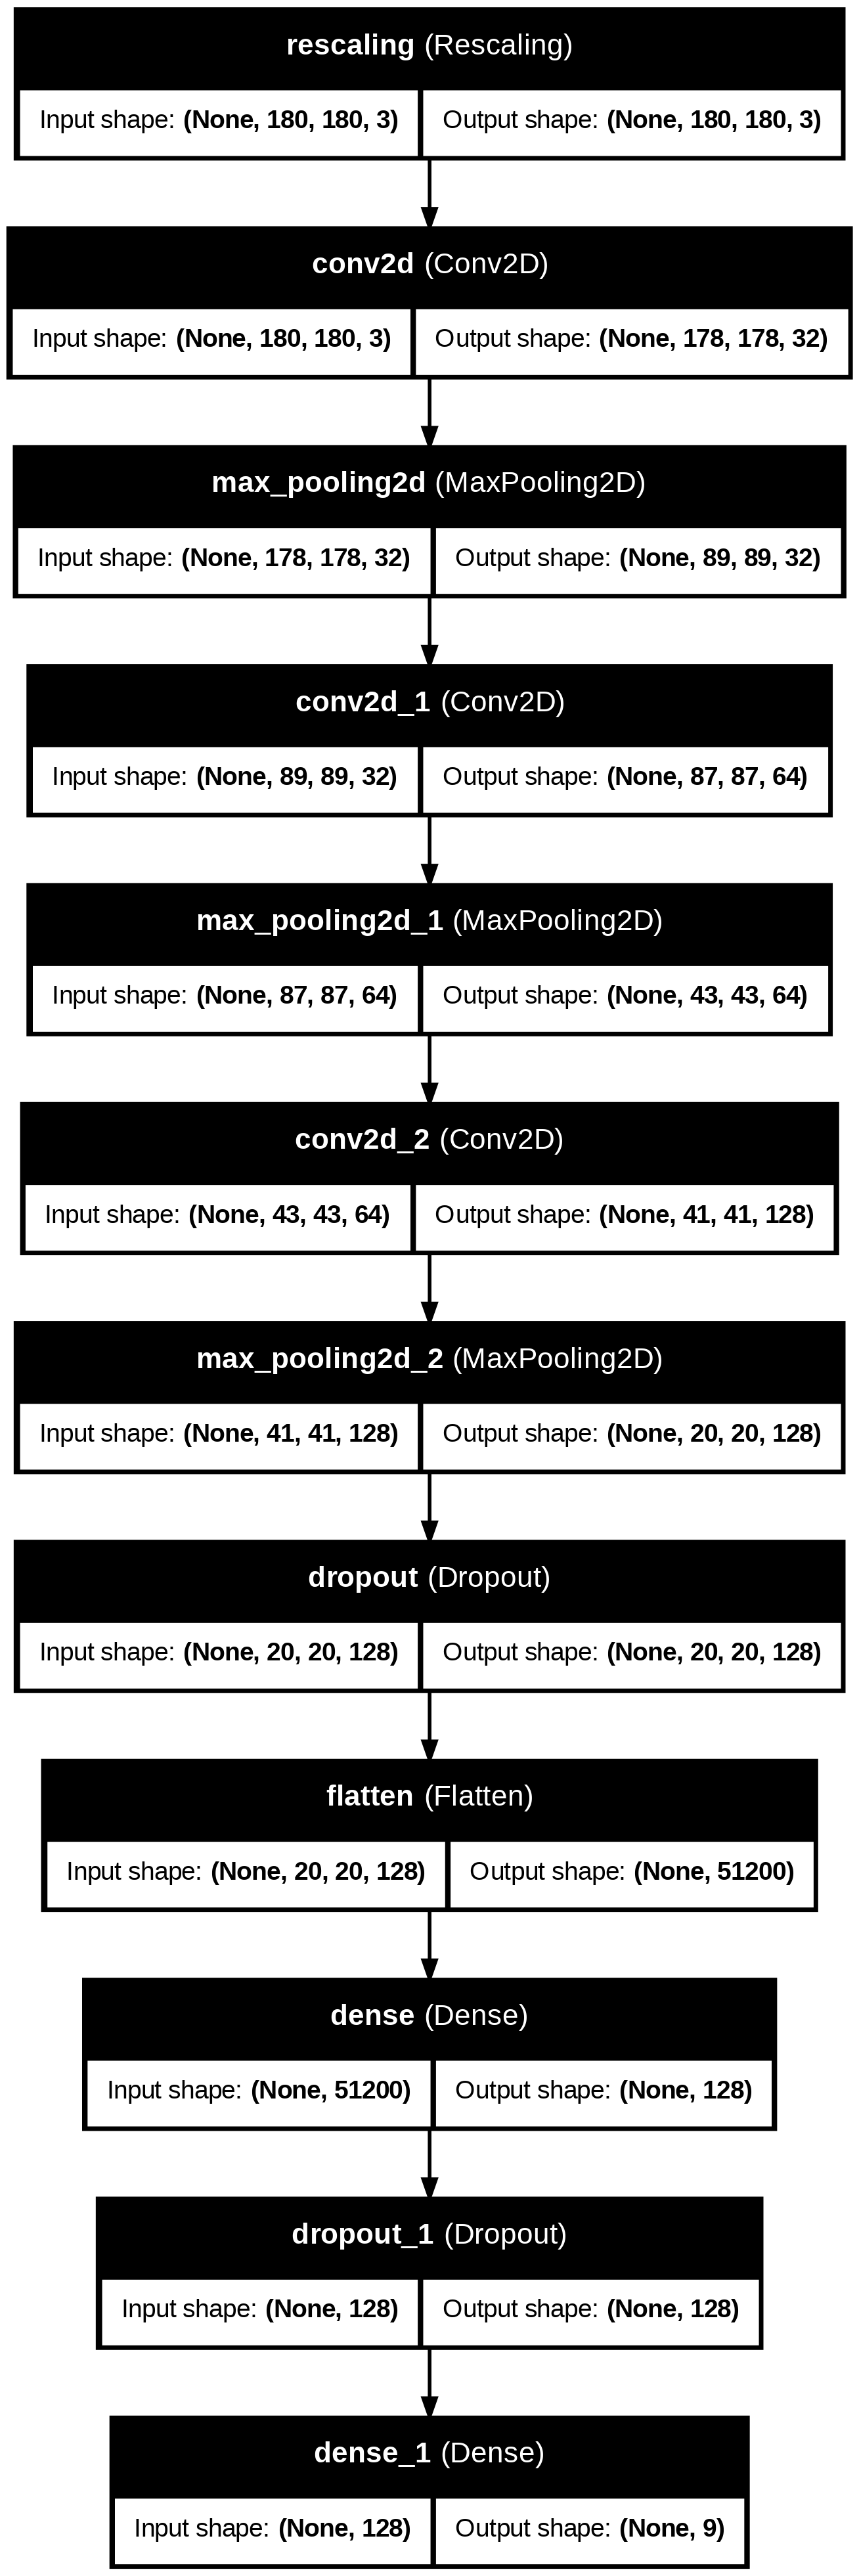

In [21]:
# vizualizing the model
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [22]:
#Compile the Model

#Adam optimization: is a stochastic gradient descent method that is based on adaptive estimation of first-order and second-order moments.
#categorical_crossentropy: Used as a loss function for multi-class classification model where there are two or more output labels.

model.compile(optimizer="Adam",loss="categorical_crossentropy",metrics=["accuracy"])

#ModelCheckpoint callback is used in conjunction with training using model.fit() to save a model or weights (in a checkpoint file) at some interval,
#so the model or weights can be loaded later to continue the training from the state saved.
checkpoint = ModelCheckpoint("model.h5",monitor="val_accuracy",save_best_only=True,mode="auto",verbose=1)

#Stop training when a monitored metric has stopped improving.
earlystop = EarlyStopping(monitor="val_accuracy",patience=5,mode="auto",verbose=1)

In [23]:
# Train the model
epochs = 20
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,callbacks=[checkpoint,earlystop])

Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1366 - loss: 2.3797
Epoch 1: val_accuracy improved from -inf to 0.25761, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - accuracy: 0.1367 - loss: 2.3787 - val_accuracy: 0.2576 - val_loss: 1.9696
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3194 - loss: 1.7758
Epoch 2: val_accuracy improved from 0.25761 to 0.43653, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.3196 - loss: 1.7752 - val_accuracy: 0.4365 - val_loss: 1.4747
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4067 - loss: 1.5140
Epoch 3: val_accuracy improved from 0.43653 to 0.45731, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.4068 - loss: 1.5140 - val_accuracy: 0.4573 - val_loss: 1.3761
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4533 - loss: 1.4245
Epoch 4: val_accuracy improved from 0.45731 to 0.50186, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 416s 2s/step - accuracy: 0.4534 - loss: 1.4245 - val_accuracy: 0.5019 - val_loss: 1.3437
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4873 - loss: 1.3370
Epoch 5: val_accuracy improved from 0.50186 to 0.50705, saving model to model.h5


...

169/169 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.6767 - loss: 0.8541 - val_accuracy: 0.7045 - val_loss: 0.7945
Epoch 12/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7096 - loss: 0.7767
Epoch 12: val_accuracy did not improve from 0.70453
169/169 ━━━━━━━━━━━━━━━━━━━━ 420s 2s/step - accuracy: 0.7096 - loss: 0.7768 - val_accuracy: 0.6622 - val_loss: 0.8648
Epoch 13/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7194 - loss: 0.7554
Epoch 13: val_accuracy did not improve from 0.70453
169/169 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - accuracy: 0.7194 - loss: 0.7554 - val_accuracy: 0.6852 - val_loss: 0.8228
Epoch 14/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7231 - loss: 0.7094
Epoch 14: val_accuracy improved from 0.70453 to 0.72977, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.7231 - loss: 0.7096 - val_accuracy: 0.7298 - val_loss: 0.7348
Epoch 15/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7697 - loss: 0.6324
Epoch 15: val_accuracy improved from 0.72977 to 0.76392, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.7696 - loss: 0.6326 - val_accuracy: 0.7639 - val_loss: 0.6713
Epoch 16/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7667 - loss: 0.6067
Epoch 16: val_accuracy improved from 0.76392 to 0.76615, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.7667 - loss: 0.6067 - val_accuracy: 0.7661 - val_loss: 0.6263
Epoch 17/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7776 - loss: 0.5783
Epoch 17: val_accuracy did not improve from 0.76615
169/169 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.7776 - loss: 0.5784 - val_accuracy: 0.5754 - val_loss: 1.5290
Epoch 18/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7237 - loss: 0.7810
Epoch 18: val_accuracy improved from 0.76615 to 0.79881, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step - accuracy: 0.7239 - loss: 0.7803 - val_accuracy: 0.7988 - val_loss: 0.5680
Epoch 19/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7803 - loss: 0.5603
Epoch 19: val_accuracy did not improve from 0.79881
169/169 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step - accuracy: 0.7803 - loss: 0.5605 - val_accuracy: 0.7966 - val_loss: 0.5592
Epoch 20/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8000 - loss: 0.5115
Epoch 20: val_accuracy did not improve from 0.79881
169/169 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step - accuracy: 0.8000 - loss: 0.5114 - val_accuracy: 0.7595 - val_loss: 0.5769


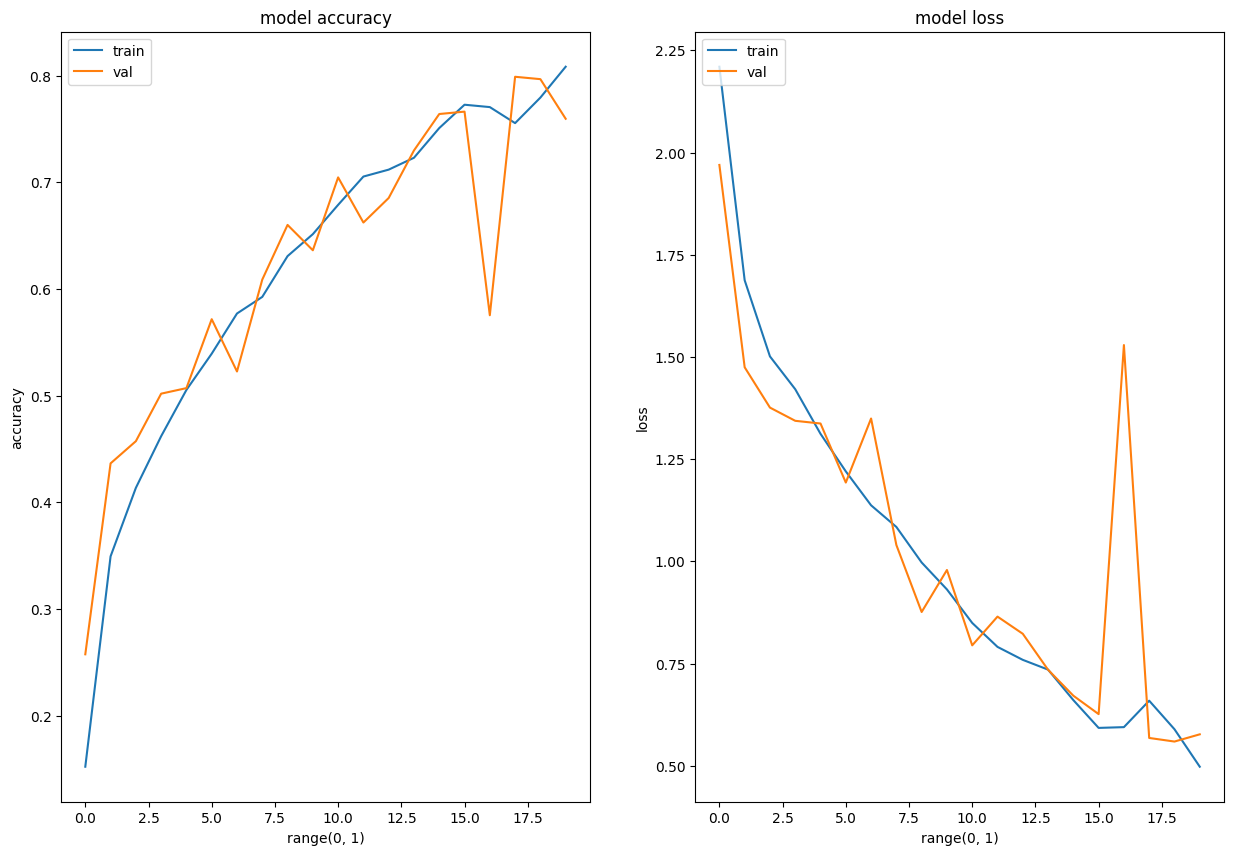

In [24]:
# Plot the training curves

epochs_range = range(earlystop.stopped_epoch+1)

plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)

#Plot Model Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel(epochs_range)
plt.legend(['train', 'val'], loc='upper left')

#Plot Model Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel(epochs_range)
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [25]:
from google.colab import files
uploaded = files.upload()


Saving ISIC_0011193.jpg to ISIC_0011193 (2).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Actual Class basal cell carcinoma
Predictive Class nevus


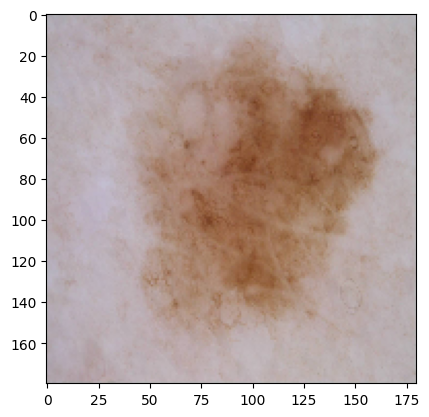

In [26]:
from glob import glob
Test_image_path = os.path.join(data_dir_test, class_names[3], '*')
Test_image = glob(Test_image_path)
Test_image = load_img(Test_image[-1],target_size=(180,180,3))
plt.imshow(Test_image)
plt.grid(False)

img = np.expand_dims(Test_image,axis=0)
pred = model.predict(img)
pred = np.argmax(pred)
pred_class = class_names[pred]
print("Actual Class "+ class_names[1] +'\n'+ "Predictive Class "+pred_class )